<a href="https://www.kaggle.com/code/lalit7881/shoes-sales-dataset-analysis-eda?scriptVersionId=314209732" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/shoes-sales-dataset/shoes_sales_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/shoes-sales-dataset/shoes_sales_dataset.csv")

In [3]:
df.head()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48


In [4]:
df.tail()

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
995,S996,2025-06-06,Puma,Sneakers,Red,India,Online,50.15,6,300.90
996,S997,2025-08-14,Adidas,Casual,Green,France,Online,231.81,2,463.62
997,S998,2025-02-13,Skechers,Running,White,India,Online,60.10,4,240.40
998,S999,2025-05-28,Puma,Boots,Black,France,Retail Store,239.05,1,239.05
999,S1000,2025-08-30,Puma,Casual,Green,India,Online,128.12,1,128.12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [6]:
df.describe()

,Price_USD,Units_Sold,Revenue_USD
count,1000.000000,1000.000000,1000.00000
mean,137.856420,10.584000,1453.18603
std,64.270059,5.842181,1112.32648
min,31.020000,1.000000,32.38000
25%,81.915000,6.000000,561.05000
50%,139.295000,10.000000,1132.62500
75%,193.752500,16.000000,2163.35000
max,249.940000,20.000000,4938.40000


In [7]:
df.isnull().sum()

Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Sale_ID           object
Date              object
Brand             object
Shoe_Type         object
Color             object
Country           object
Sales_Channel     object
Price_USD        float64
Units_Sold         int64
Revenue_USD      float64
dtype: object

In [10]:
df.shape

(1000, 10)

In [11]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

In [12]:
df.nunique()

Sale_ID          1000
Date              342
Brand               6
Shoe_Type           6
Color               6
Country             7
Sales_Channel       3
Price_USD         979
Units_Sold         20
Revenue_USD       996
dtype: int64

## EDA

  Sale_ID       Date        Brand Shoe_Type  Color Country Sales_Channel  \
0      S1 2025-11-24         Nike     Boots   Blue      UK        Online   
1      S2 2025-03-13     Skechers     Boots   Grey     USA          Mall   
2      S3 2025-08-05         Nike   Running  White      UK          Mall   
3      S4 2025-11-05  New Balance    Casual  Green     UAE          Mall   
4      S5 2025-10-07       Adidas    Formal   Grey  France        Online   

   Price_USD  Units_Sold  Revenue_USD  
0     112.40           4       449.60  
1     239.16           4       956.64  
2     191.04           2       382.08  
3     161.70           1       161.70  
4      64.32          14       900.48  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sale_ID        1000 non-null   object        
 1   Date           1000 non-null   datetime

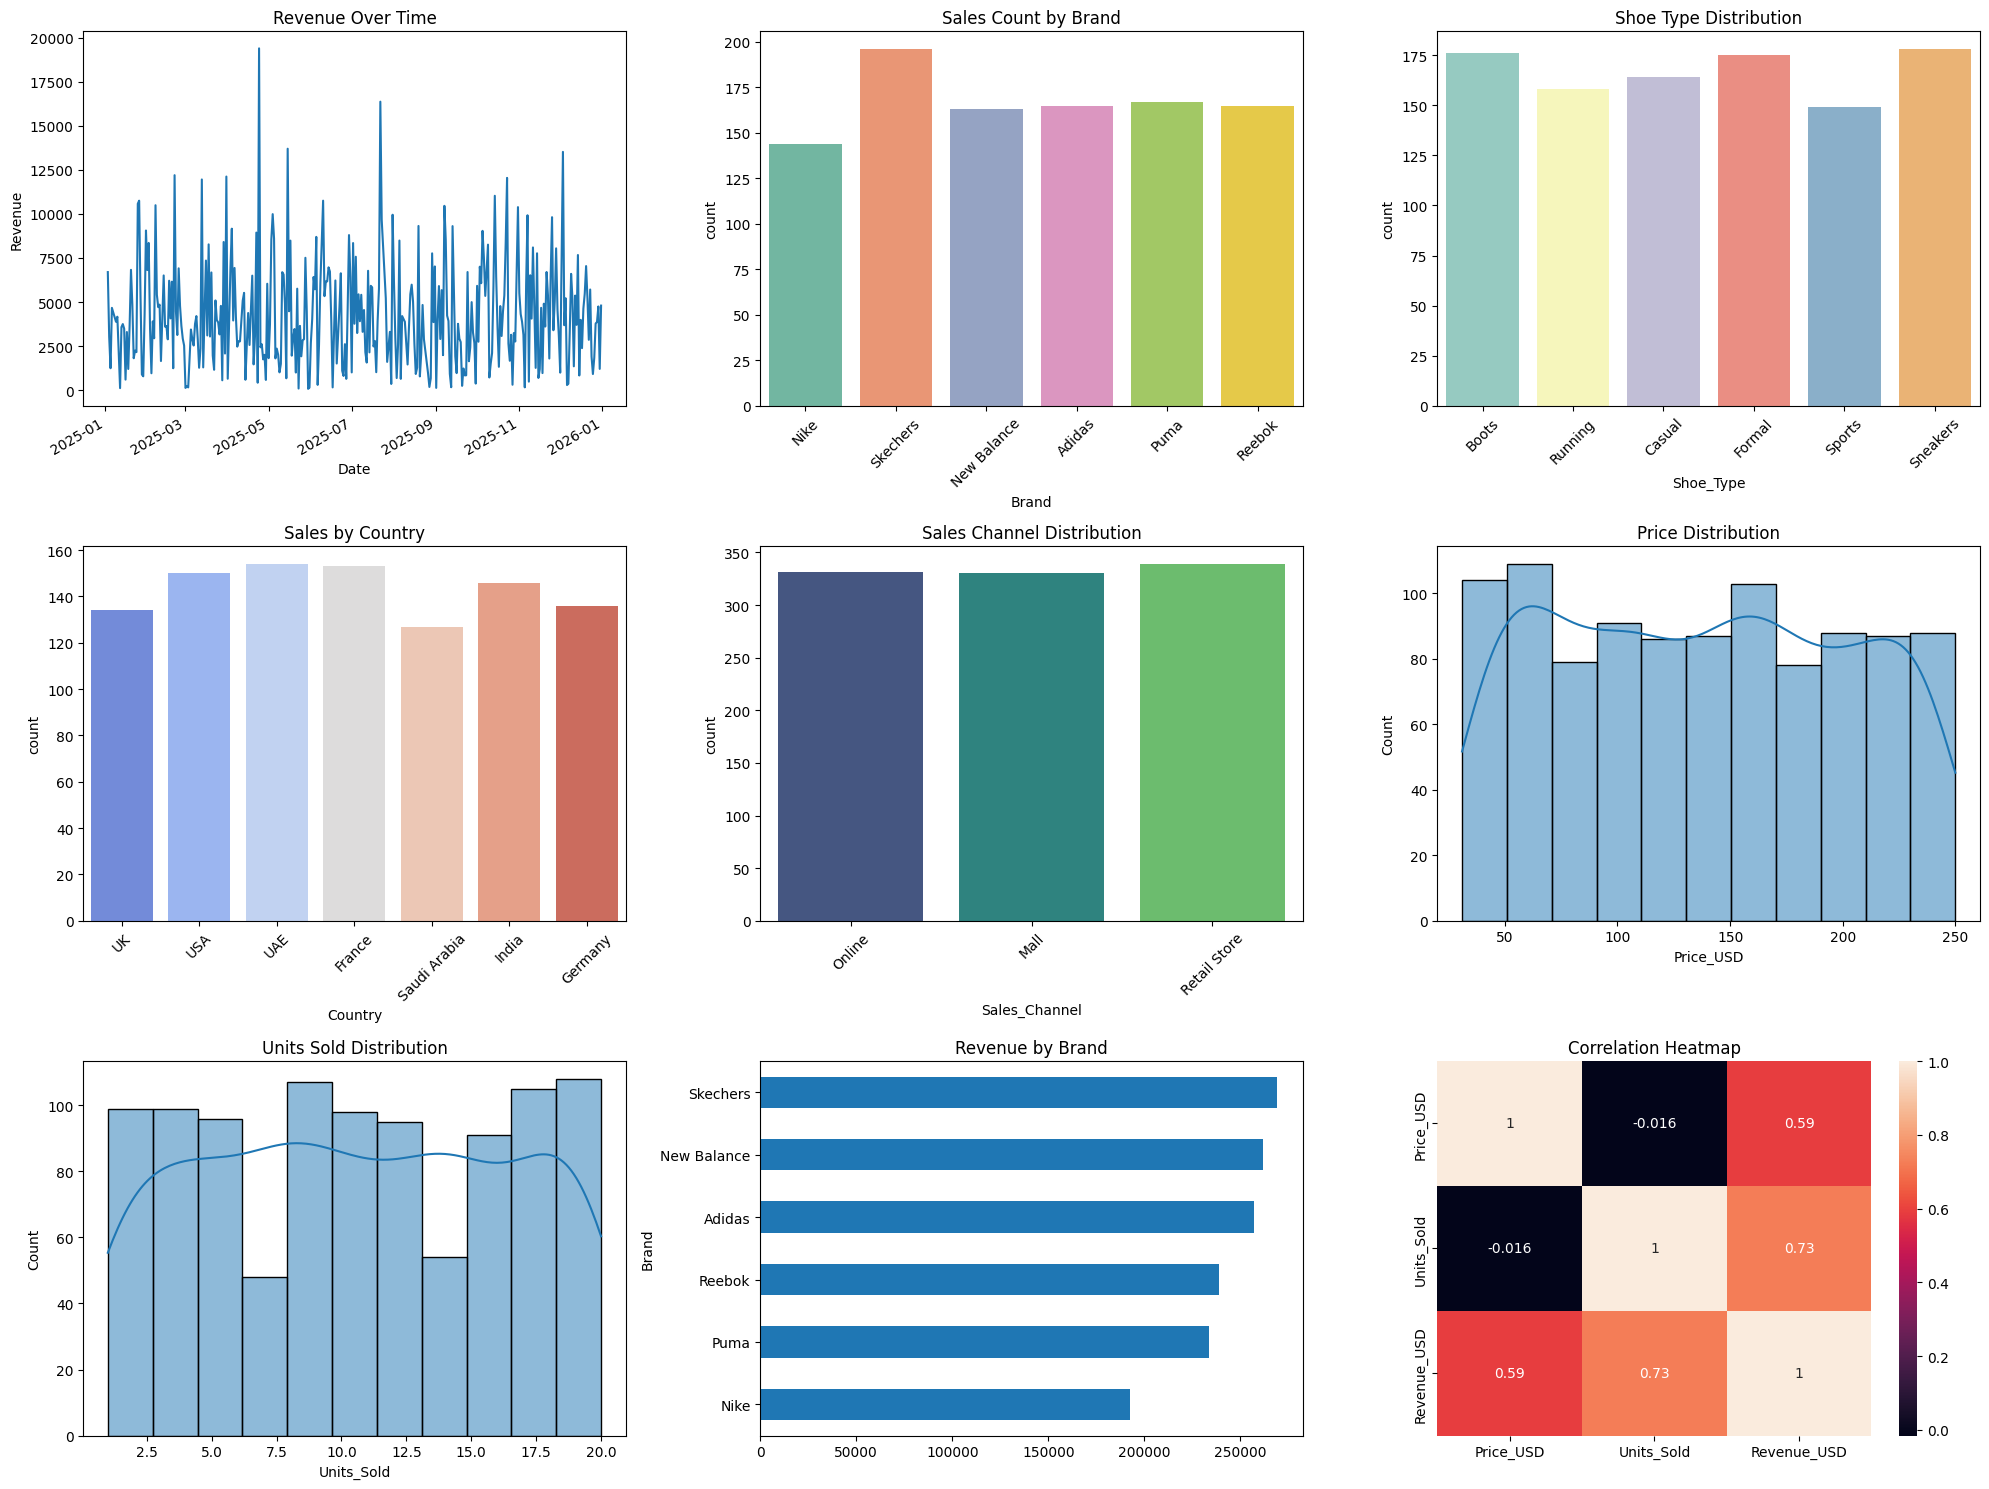

In [13]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# =========================
# BASIC INFO
# =========================
print(df.head())
print(df.info())

# =========================
# CREATE FIGURE
# =========================
plt.figure(figsize=(20, 15))

# =========================
# 1. SALES TREND OVER TIME
# =========================
plt.subplot(3, 3, 1)
df.groupby('Date')['Revenue_USD'].sum().plot()
plt.title("Revenue Over Time", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Revenue")

# =========================
# 2. BRAND DISTRIBUTION
# =========================
plt.subplot(3, 3, 2)
sns.countplot(data=df, x='Brand', palette='Set2')
plt.title("Sales Count by Brand")
plt.xticks(rotation=45)

# =========================
# 3. SHOE TYPE SALES
# =========================
plt.subplot(3, 3, 3)
sns.countplot(data=df, x='Shoe_Type', palette='Set3')
plt.title("Shoe Type Distribution")
plt.xticks(rotation=45)

# =========================
# 4. SALES BY COUNTRY
# =========================
plt.subplot(3, 3, 4)
sns.countplot(data=df, x='Country', palette='coolwarm')
plt.title("Sales by Country")
plt.xticks(rotation=45)

# =========================
# 5. SALES CHANNEL
# =========================
plt.subplot(3, 3, 5)
sns.countplot(data=df, x='Sales_Channel', palette='viridis')
plt.title("Sales Channel Distribution")
plt.xticks(rotation=45)

# =========================
# 6. PRICE DISTRIBUTION
# =========================
plt.subplot(3, 3, 6)
sns.histplot(df['Price_USD'], kde=True)
plt.title("Price Distribution")

# =========================
# 7. UNITS SOLD DISTRIBUTION
# =========================
plt.subplot(3, 3, 7)
sns.histplot(df['Units_Sold'], kde=True)
plt.title("Units Sold Distribution")

# =========================
# 8. REVENUE BY BRAND
# =========================
plt.subplot(3, 3, 8)
df.groupby('Brand')['Revenue_USD'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Brand")

# =========================
# 9. CORRELATION HEATMAP
# =========================
plt.subplot(3, 3, 9)
corr = df[['Price_USD', 'Units_Sold', 'Revenue_USD']].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")

# =========================
# FINAL LAYOUT
# =========================
plt.tight_layout()
plt.show()

## Feature engineering


===== Logistic Regression =====
Accuracy: 0.895
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       100
           1       0.89      0.90      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200


===== Decision Tree =====
Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


===== Random Forest =====
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       100
           1       0.99      0.91      0.95       100

    accuracy                           0.95      

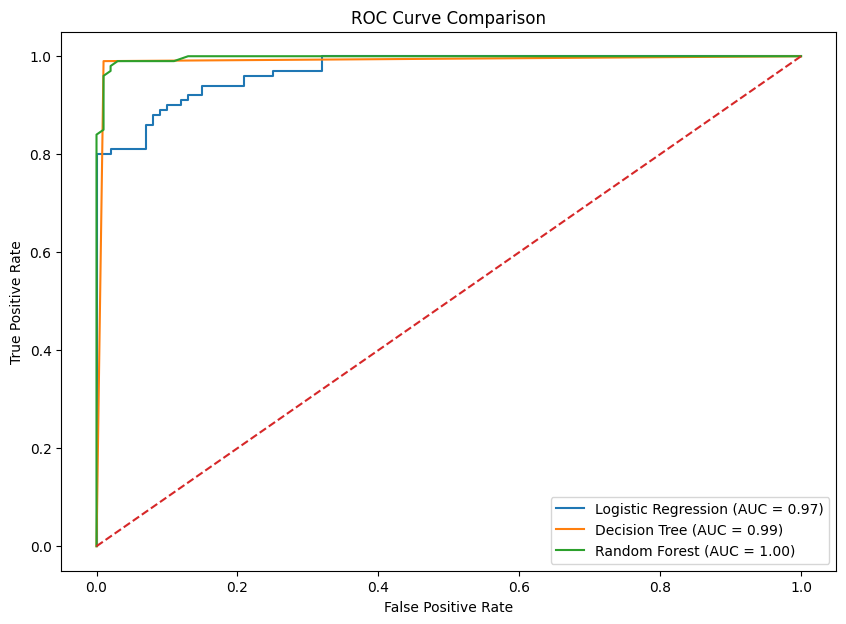

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# =========================
# TARGET CREATION (NO LEAKAGE)
# =========================
median_revenue = df['Revenue_USD'].median()
df['Target'] = (df['Revenue_USD'] > median_revenue).astype(int)

# =========================
# DROP LEAKAGE COLUMN
# =========================
# Revenue should NOT be used since target is derived from it
df = df.drop(columns=['Revenue_USD', 'Sale_ID'])

# =========================
# FEATURE ENGINEERING
# =========================
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df = df.drop(columns=['Date'])

# =========================
# SPLIT FEATURES & TARGET
# =========================
X = df.drop(columns=['Target'])
y = df['Target']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# COLUMN TYPES
# =========================
cat_cols = ['Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel']
num_cols = ['Price_USD', 'Units_Sold', 'Year', 'Month', 'Day']

# =========================
# PREPROCESSING PIPELINE
# =========================
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# =========================
# TRAIN + EVALUATE
# =========================
plt.figure(figsize=(10, 7))

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =========================
# ROC CURVE PLOT
# =========================
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!!!!